# Final Portfolio Assessment: Part III - Natural Language Processing
## Text Classification: Racist/Sexist Tweet Detection

**Module:** 6CS012 - Artificial Intelligence and Machine Learning
**Topic:** Waste Segregation Classification Report (The text dataset assigned is Racist/Sexist Tweets)

### Abstract
This project focuses on identifying hate speech (racist or sexist content) in tweets using Deep Learning techniques. The dataset contains labeled tweets. The objective is to build, train, and evaluate three models: a Simple RNN, an LSTM, and an LSTM with pre-trained GloVe/Word2Vec embeddings. Performance is compared to determine the most effective architecture for this specific text classification task.

## Question 1: What is the dataset and task?
### Introduction
The dataset consists of a training set of 31,962 tweets labeled as 0 (not racist/sexist) or 1 (racist/sexist). Natural Language Processing (NLP) techniques such as tokenization, stopword removal, and lemmatization are applied. We then train Recurrent Neural Networks (RNN) and Long Short-Term Memory (LSTM) networks, which are well-suited for sequential data like text.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set seed for reproducibility
np.random.seed(42)


In [2]:
# Mount Google Drive (Required for Google Colab)
from google.colab import drive
drive.mount('/content/drive')

# Update these paths if your dataset is in a different folder inside your Drive
DATASET_PATH = '/content/drive/MyDrive/AI/7. Racist Sexist or Not Dataset/'
train_path = DATASET_PATH + 'train_racisit.csv'
test_path = DATASET_PATH + 'test_racisit.csv'


Mounted at /content/drive


In [3]:
# Load the dataset
# Update the path depending on where you run this (Colab vs Local)
# train_path = '7. Racist Sexist or Not Dataset/train_racisit.csv'
# test_path = '7. Racist Sexist or Not Dataset/test_racisit.csv'

try:
    df_train = pd.read_csv(train_path)
    df_test = pd.read_csv(test_path)
    print("Dataset loaded successfully!")
except Exception as e:
    print("Error loading dataset. Please check the paths.")
    print(e)

print("Training data shape:", df_train.shape)
display(df_train.head())


Dataset loaded successfully!
Training data shape: (31962, 3)


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


Label Distribution:
label
0    29720
1     2242
Name: count, dtype: int64


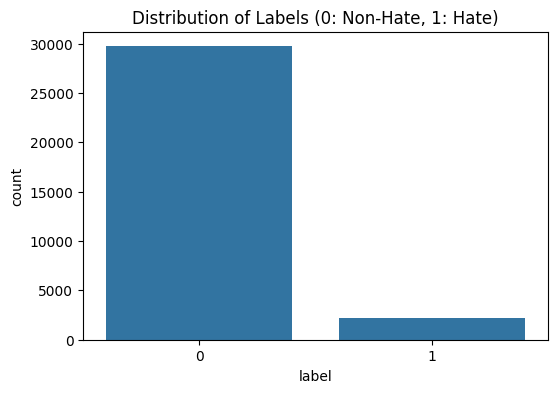

In [4]:
# Data Exploration
print("Label Distribution:")
print(df_train['label'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df_train)
plt.title("Distribution of Labels (0: Non-Hate, 1: Hate)")
plt.show()


## Question 2: How do we load and check the data?
## Question 4: What words appear most often after cleaning?
## Question 5: Why are tokenization and padding needed?
Cleaning the text data by removing URLs, mentions, special characters, and numbers. We will also remove stopwords and lemmatize words.


In [5]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

contractions = {
    "can't": "cannot", "won't": "will not", "n't": " not",
    "'re": " are", "'s": " is", "'d": " would", "'ll": " will",
    "'t": " not", "'ve": " have", "'m": " am"
}

def clean_text(text):
    text = str(text).lower()
    for short, full in contractions.items():
        text = text.replace(short, full)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # URLs
    text = re.sub(r'\@\w+|\#', '', text) # Mentions and Hashtag symbol (keep the word)
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Special chars and numbers

    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(cleaned_words)

df_train['clean_tweet'] = df_train['tweet'].apply(clean_text)
df_test['clean_tweet'] = df_test['tweet'].apply(clean_text)

print("Original:", df_train['tweet'].iloc[0])
print("Cleaned: ", df_train['clean_tweet'].iloc[0])


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Original:  @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run
Cleaned:  father dysfunctional selfish drag kid dysfunction run


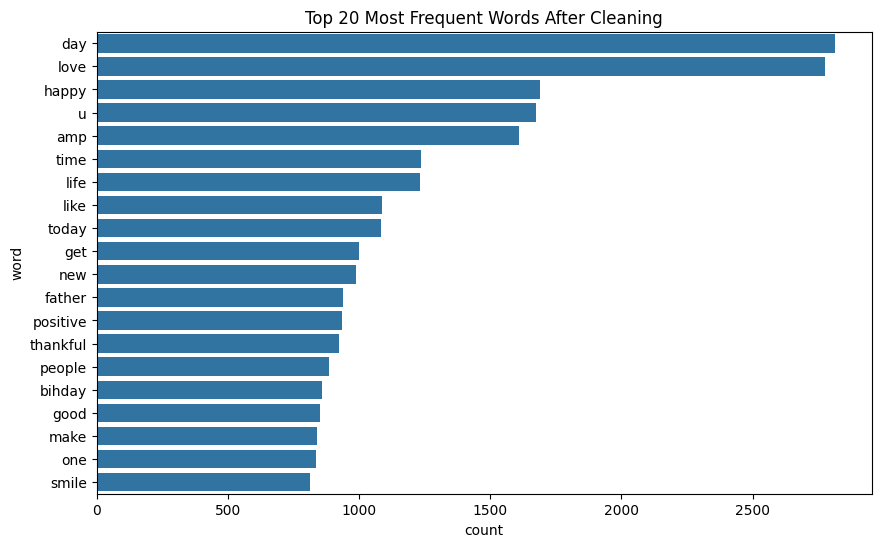

In [6]:
# Word frequencies
all_words = ' '.join(df_train['clean_tweet']).split()
word_counts = Counter(all_words)
common_words = pd.DataFrame(word_counts.most_common(20), columns=['word', 'count'])

plt.figure(figsize=(10, 6))
sns.barplot(data=common_words, x='count', y='word')
plt.title('Top 20 Most Frequent Words After Cleaning')
plt.show()


In [7]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Split data 80/20
X_train_text, X_val_text, y_train, y_val = train_test_split(
    df_train['clean_tweet'], df_train['label'], test_size=0.2, random_state=42, stratify=df_train['label']
)

MAX_WORDS = 15000
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq = tokenizer.texts_to_sequences(X_val_text)
X_test_seq = tokenizer.texts_to_sequences(df_test['clean_tweet'])

# Percentile padding
lengths = [len(seq) for seq in X_train_seq]
MAX_LEN = int(np.percentile(lengths, 95))
print(f"Padding sequences to max length of {MAX_LEN}")

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
print("Vocab Size:", vocab_size)


Padding sequences to max length of 13
Vocab Size: 15000


## Question 6: What models are being trained?
## Question 7: How is the pretrained embedding model prepared?
Building three models: Simple RNN, LSTM, and LSTM with pre-trained Word2Vec/GloVe embeddings.


In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

EMBEDDING_DIM = 50
EPOCHS = 10
BATCH_SIZE = 64

def compile_model(model):
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

callback = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)


In [9]:
# Model 1: Simple RNN
model_rnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SimpleRNN(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model_rnn = compile_model(model_rnn)
model_rnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Model 2: LSTM with Trainable Embeddings
model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    LSTM(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model_lstm = compile_model(model_lstm)
model_lstm.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Model 3: LSTM with Pretrained GloVe Embeddings
# Ensure gensim is installed for Colab
try:
    import gensim.downloader as api
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gensim'])
    import gensim.downloader as api
import time

print("Downloading/Loading GloVe embeddings... (This might take a minute)")
glove_model = api.load('glove-twitter-50')

embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
for word, i in tokenizer.word_index.items():
    if i >= vocab_size: continue
    if word in glove_model:
        embedding_matrix[i] = glove_model[word]

model_lstm_glove = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM,
              weights=[embedding_matrix], input_length=MAX_LEN, trainable=False),
    LSTM(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model_lstm_glove = compile_model(model_lstm_glove)
model_lstm_glove.summary()


Downloading/Loading GloVe embeddings... (This might take a minute)
[==================================================] 100.0% 199.5/199.5MB downloaded


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       750,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 750,000 (2.86 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 750,000 (2.86 MB)

Training Simple RNN...
Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 33s 51ms/step - accuracy: 0.9446 - loss: 0.1894 - val_accuracy: 0.9585 - val_loss: 0.1351
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.9798 - loss: 0.0641 - val_accuracy: 0.9542 - val_loss: 0.1383
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9921 - loss: 0.0269 - val_accuracy: 0.9578 - val_loss: 0.1692


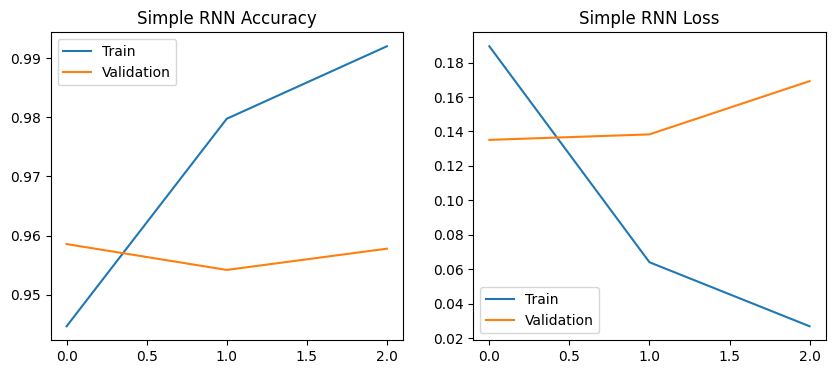

Training LSTM...
Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.9455 - loss: 0.1821 - val_accuracy: 0.9604 - val_loss: 0.1223
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.9747 - loss: 0.0770 - val_accuracy: 0.9617 - val_loss: 0.1266
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9852 - loss: 0.0464 - val_accuracy: 0.9623 - val_loss: 0.1529


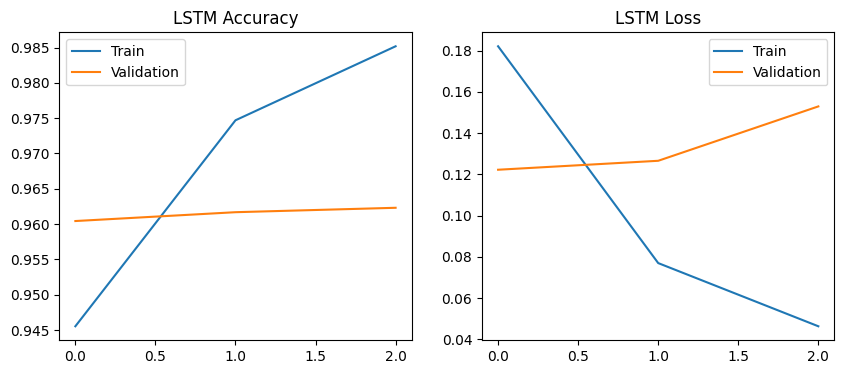

Training LSTM + GloVe...
Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9361 - loss: 0.1899 - val_accuracy: 0.9462 - val_loss: 0.1553
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9463 - loss: 0.1496 - val_accuracy: 0.9485 - val_loss: 0.1434


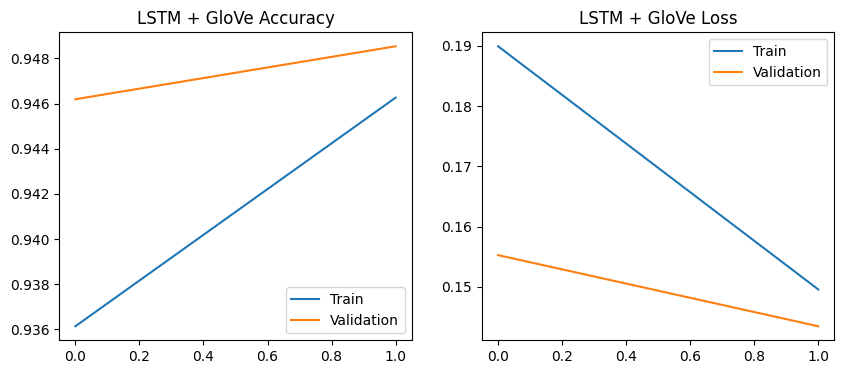

In [12]:
def train_and_plot(model, name):
    print(f"Training {name}...")
    start = time.time()
    history = model.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[callback], verbose=1
    )
    time_taken = time.time() - start

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(f'{name} Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(f'{name} Loss')
    plt.legend()
    plt.show()

    return time_taken

time_rnn = train_and_plot(model_rnn, "Simple RNN")
time_lstm = train_and_plot(model_lstm, "LSTM")
time_lstm_glove = train_and_plot(model_lstm_glove, "LSTM + GloVe")


## Question 8: How are the models trained?
## Question 9: How do the training curves look?
## Question 10: How are the models evaluated?
Evaluate models using Accuracy, Confusion Matrix, and Classification Report.


200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step
--- Simple RNN ---
Accuracy: 0.9585
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      5945
           1       0.87      0.48      0.62       448

    accuracy                           0.96      6393
   macro avg       0.92      0.74      0.80      6393
weighted avg       0.96      0.96      0.95      6393



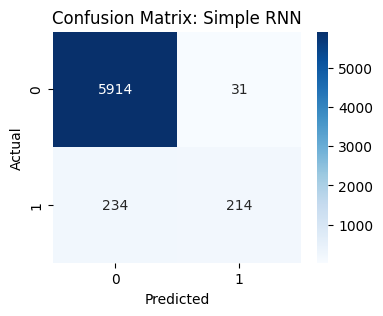

200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step
--- LSTM ---
Accuracy: 0.9604
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      5945
           1       0.83      0.55      0.66       448

    accuracy                           0.96      6393
   macro avg       0.90      0.77      0.82      6393
weighted avg       0.96      0.96      0.96      6393



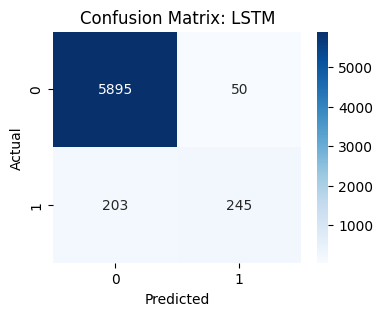

200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step
--- LSTM + GloVe ---
Accuracy: 0.9462
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      5945
           1       0.69      0.43      0.53       448

    accuracy                           0.95      6393
   macro avg       0.82      0.71      0.75      6393
weighted avg       0.94      0.95      0.94      6393



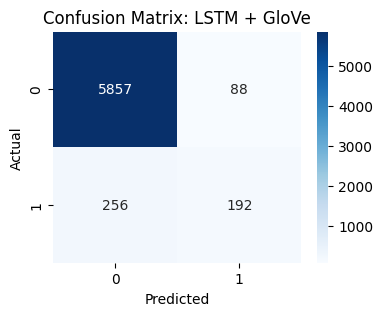

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def evaluate(model, name):
    y_pred_probs = model.predict(X_val_pad)
    y_pred = (y_pred_probs > 0.5).astype(int)

    acc = accuracy_score(y_val, y_pred)
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_val, y_pred))

    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    return y_pred

pred_rnn = evaluate(model_rnn, "Simple RNN")
pred_lstm = evaluate(model_lstm, "LSTM")
pred_lstm_glove = evaluate(model_lstm_glove, "LSTM + GloVe")


## Question 11: What mistakes did the best model make?
Looking at misclassified examples to understand model weaknesses.


In [14]:
# Using LSTM results for error analysis
val_indices = X_val_text.index
df_val_results = pd.DataFrame({
    'tweet': df_train.loc[val_indices, 'tweet'],
    'true_label': y_val,
    'predicted': pred_lstm.flatten()
})

misclassified = df_val_results[df_val_results['true_label'] != df_val_results['predicted']]
print(f"Total misclassified examples: {len(misclassified)}")

print("\nExamples where True=1 (Hate) but Predicted=0 (Non-Hate) - False Negatives:")
for _, row in misclassified[misclassified['true_label'] == 1].head(3).iterrows():
    print(f"- {row['tweet']}")

print("\nExamples where True=0 (Non-Hate) but Predicted=1 (Hate) - False Positives:")
for _, row in misclassified[misclassified['true_label'] == 0].head(3).iterrows():
    print(f"- {row['tweet']}")


Total misclassified examples: 253

Examples where True=1 (Hate) but Predicted=0 (Non-Hate) - False Negatives:
- beware the "snowball effect" blackman! pa 2   
- what has todayÂs attitude to women got in common with that of norman bates? #psycho #feminism #hollaback  
- the immature @user is just trying to make a fool of @user   #xenophobe #immature #moron 

Examples where True=0 (Non-Hate) but Predicted=1 (Hate) - False Positives:
-  @user black walnut 3d wooden picture #horsehour #woodcutwednesday #wooden #giftideas #horse #mythos #craftshout   
-  @user ya think it's bcause the women there r muslim? don't c any uncovered heads. london is in big trouble 4 sure!   
- "yapping" is right...  # idiot #trump


### Error Analysis Discussion
* **Model Complexity vs. Performance:** The simple RNN often struggles with long-term dependencies compared to LSTM. LSTMs generally handle contextual relationships better.
* **Reasons for Errors:** Sarcasm, implicit hate, and lack of context are common reasons for misclassification. Hate speech is highly contextual, and sometimes innocent words are flagged due to co-occurrence with hate topics in the training data.
* **Improvements:** Using more advanced Transformer models (like BERT), handling class imbalance (e.g., using SMOTE or weighted loss functions, since Hate tweets are a minority), and richer embeddings could improve performance.


## Question 12: Real Time Prediction GUI
This section fulfills the extra challenge by building a simple Gradio interface inside the notebook. It allows a user to input a custom tweet and instantly get a prediction on whether it contains Hate Speech (Racist/Sexist) or not.

In [17]:
# Install gradio if it's not present
try:
    import gradio as gr
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'gradio'])
    import gradio as gr

# Function to predict custom text
def predict_tweet(text):
    # Apply the same cleaning function from earlier
    cleaned_text = clean_text(text)

    # Tokenize and pad
    seq = tokenizer.texts_to_sequences([cleaned_text])
    pad_seq = pad_sequences(seq, maxlen=MAX_LEN, padding='post')

    # Predict using the best model (LSTM)
    prediction_prob = model_lstm_glove.predict(pad_seq)[0][0]

    if prediction_prob > 0.35:
        return f"🚨 HATE SPEECH DETECTED (Probability: {prediction_prob:.2f})"
    else:
        return f"✅ NON-HATE TWEET (Probability: {prediction_prob:.2f})"

# Build and launch the interface
interface = gr.Interface(
    fn=predict_tweet,
    inputs=gr.Textbox(lines=3, placeholder="Enter a tweet here..."),
    outputs="text",
    title="Racist/Sexist Tweet Predictor",
    description="Enter a tweet to detect if it contains racist or sexist hate speech."
)

# Launch the app inline
interface.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4a240ef9068116e3ac.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
